In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
import cv2
from tqdm import tqdm
import tensorflow 
from tensorflow import keras 
from tensorflow.keras.layers import ( Dense , Dropout , Conv2D ,
 Flatten , Activation , GlobalAveragePooling2D , 
                                    )
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint , ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.utils import load_img , img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import train_test_split

In [2]:
import os

extensions = set()

for root, dirs, files in os.walk('dataset'):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext:
            extensions.add(ext)

print(extensions)


{'.png', '.jpg', '.jpeg'}


In [3]:
dir = 'dataset'

X = []
y = []

for fld in os.listdir( dir ):

    fld_path = os.path.join( dir , fld )
    print(f'Folder Name : {fld}')
    print(f'Folder Path : {fld_path}')

    jpg_images =  gb.glob( fld_path + '/*.jpg')
    jpeg_images =  gb.glob( fld_path + '/*.jpeg')
    png_images =  gb.glob( fld_path + '/*.png')

    images = jpg_images + jpeg_images + png_images

    for img in tqdm( images ) :

        img = load_img( img , color_mode='rgb' ,target_size=(224 , 224) )
        img = img_to_array( img )

        X.append( img )
        y.append( fld )    

    print(f'{fld} : Done\n{"-"*50}')
    

Folder Name : without_mask
Folder Path : dataset\without_mask


100%|██████████| 1918/1918 [00:08<00:00, 227.97it/s]


without_mask : Done
--------------------------------------------------
Folder Name : with_mask
Folder Path : dataset\with_mask


 99%|█████████▉| 1905/1915 [00:15<00:00, 176.54it/s]c:\Users\B-UNIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 1915/1915 [00:15<00:00, 120.44it/s]

with_mask : Done
--------------------------------------------------


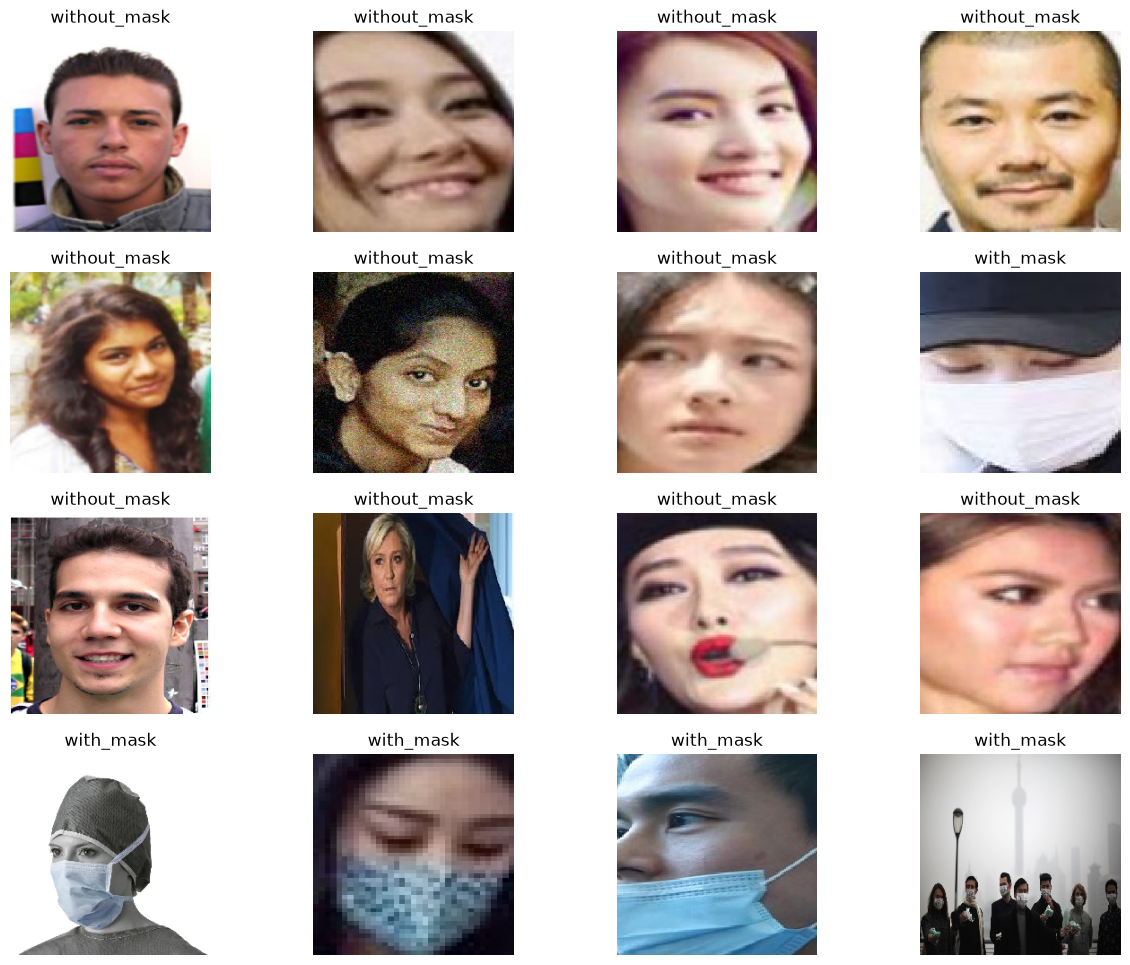

In [4]:
samples = np.random.randint( 0 , len( X ) , 16 )

plt.figure(figsize=(15 ,12))

for ind , i in enumerate( samples ) :
    plt.subplot( 4 , 4 , ind + 1)
    plt.imshow(X[i].astype('uint8') )
    plt.title(y[i])
    plt.axis('off')

plt.show()

In [5]:
X = np.array( X )
y = np.array( y )

In [6]:
y = ( y == 'with_mask').astype('int8')
pd.DataFrame( y ).value_counts()

0
0    1918
1    1915
Name: count, dtype: int64

In [7]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size=0.30 , 
                                                       random_state= 42 , stratify= y)

print(f'X train shape = {X_train.shape}')
print(f'X test shape = {X_test.shape}')
print(f'y train shape = {y_train.shape}')
print(f'y test shape = {y_test.shape}')

X train shape = (2683, 224, 224, 3)
X test shape = (1150, 224, 224, 3)
y train shape = (2683,)
y test shape = (1150,)


### stratify <> to keep the percentile of Class in Test and Validation

In [8]:
X_test , X_valid , y_test , y_valid = train_test_split( X_test , y_test , test_size=0.50 , 
                                                       random_state= 42 , stratify=y_test )

print(f'X test shape = {X_test.shape}')
print(f'y test shape = {y_test.shape}')

print(f'X valid shape = {X_valid.shape}')
print(f'y valid shape = {y_valid.shape}')

X test shape = (575, 224, 224, 3)
y test shape = (575,)
X valid shape = (575, 224, 224, 3)
y valid shape = (575,)


In [9]:
train_generator = ImageDataGenerator( 
    rotation_range= 10 , 
    width_shift_range = 0.1 , 
    height_shift_range = 0.1 , 
    zoom_range = 0.1 , 
    horizontal_flip = True
).flow( X_train , y_train , batch_size = 32 , shuffle = True )


# to convert array into batches
val_generator = ImageDataGenerator().flow( X_valid , y_valid ,
                                           batch_size= 32 , shuffle = False)

test_generator = ImageDataGenerator().flow( X_test , y_test ,
                                            batch_size= 32 , shuffle = False)


In [10]:
# MobileNetV3Large <> makes scale from 0 to 1 automatically 
# base_model <> will be used to extract features from images 
# output of base_model is : Feature Maps <> it's a map that discover to the model
#                          where are Features in the image and how strength
base_model = MobileNetV3Large(weights='imagenet' , 
                              include_top=False , input_shape=(224,224,3))

base_model.trainable = False

# feature maps = 960 * 7 * 7 : after GAPooling <> vector = 960 
# so X is a feature vector , we connect X to Dense
x = GlobalAveragePooling2D()( base_model.output )

x = Dense( 128 , activation='relu' )( x )
x = Dropout( 0.3 )( x )

x = Dense( 64 , activation='relu' )( x )
x = Dropout( 0.2 )( x )

output = Dense( 1 , activation='sigmoid')(x)

# attach output to the entire base model

model = Model( inputs = base_model.input , outputs = output )

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,127,681 (11.93 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [11]:
model.compile( optimizer= Adam() , loss='binary_crossentropy' , metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss' , patience= 10 ,
                              mode='min' ,factor = 0.1 , min_lr = 0.000001 
                              )

early_stop = EarlyStopping(monitor='val_loss' , patience= 5 ,
                          mode='min' , restore_best_weights=True # default False 
                          )

model_check_point = ModelCheckpoint(
    filepath='mask_best_model.keras' , 
    monitor='val_loss' , 
    save_best_only=True , # default False
    save_weights_only=False # default False
                                   )

callbacks = [ reduce_lr , early_stop , model_check_point ]

In [22]:
fit_history = model.fit( train_generator , batch_size= 32 , epochs= 30 , 
                         validation_data= val_generator , 
                         callbacks= callbacks 
                       )

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 76s 909ms/step - accuracy: 0.9989 - loss: 0.0053 - val_accuracy: 0.9948 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 805ms/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 0.9948 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 812ms/step - accuracy: 0.9974 - loss: 0.0064 - val_accuracy: 0.9965 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 797ms/step - accuracy: 0.9974 - loss: 0.0053 - val_accuracy: 0.9948 - val_loss: 0.0246 - learning_rate: 0.0010
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 65s 773ms/step - accuracy: 0.9985 - loss: 0.0063 - val_accuracy: 0.9965 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 760ms/step - accuracy: 0.9993 - loss: 0.0019 - val_accuracy: 0.9948 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 762ms/step - accuracy: 0.9993 - loss: 0.

In [23]:
acc = fit_history.history['accuracy']
loss = fit_history.history['loss']
val_acc = fit_history.history['val_accuracy']
val_loss = fit_history.history['val_loss']

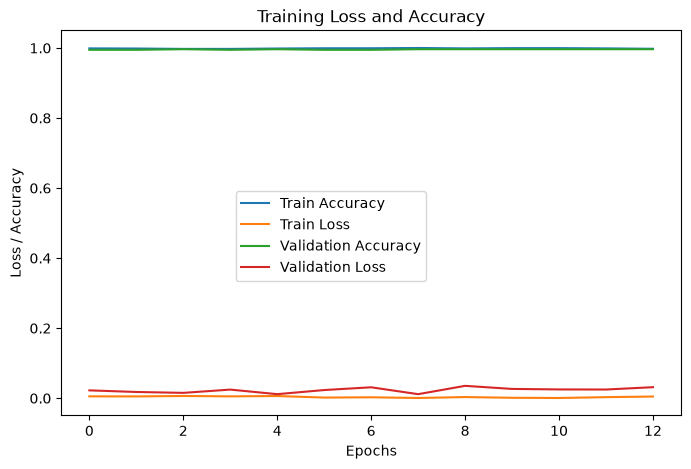

In [24]:
epochs = np.arange( 0 , len( acc ) )

plt.figure(figsize=(8 , 5))

plt.plot( epochs , acc , label = 'Train Accuracy')
plt.plot( epochs , loss , label = 'Train Loss')
plt.plot( epochs , val_acc , label = 'Validation Accuracy')
plt.plot( epochs , val_loss , label = 'Validation Loss')

plt.title('Training Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss / Accuracy')
plt.legend( bbox_to_anchor = (0.6 , 0.6)) # loc = 'center'

plt.show()

In [25]:
y_pred_proba = model.predict( X_test )
y_pred_proba[:5]

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step


array([[1.0000000e+00],
       [8.3813951e-08],
       [9.1836183e-10],
       [9.9999934e-01],
       [1.0000000e+00]], dtype=float32)

In [26]:
y_pred = ( y_pred_proba >= 0.50 ).astype('int8')
y_pred[:10]

array([[1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1]], dtype=int8)

In [27]:
print(f'predictions = {y_pred[ : 20].ravel()}')
print(f'    Actuals = {y_test[ : 20]}')

predictions = [1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1]
    Actuals = [1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1]


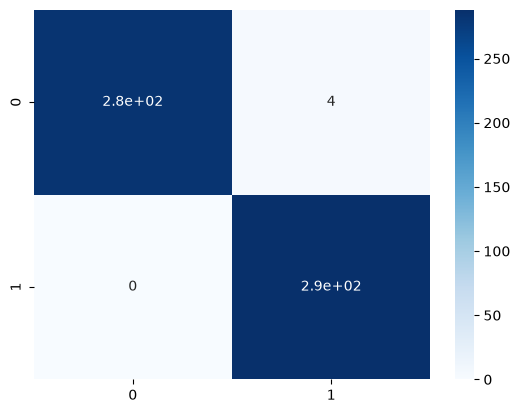

In [28]:
CM = confusion_matrix( y_test , y_pred )

sns.heatmap( CM , cmap='Blues' , annot=True)
plt.show()

In [29]:
print( classification_report( y_test , y_pred ))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       287
           1       0.99      1.00      0.99       288

    accuracy                           0.99       575
   macro avg       0.99      0.99      0.99       575
weighted avg       0.99      0.99      0.99       575

